# V16 - S4 Deep Analysis: qty x T^(-0.35)

V15 showed that a fractional threshold exponent (S4, alpha=0.35) significantly
outperforms the V9 baseline (silhouette 0.419 vs 0.289). This notebook:

1. Builds V9 and S4(alpha=0.35) cleanly side-by-side
2. Compares them visually against the reference
3. Analyses cluster memberships in depth: which recipes moved, and does
   the new grouping make more chemical/sensory sense?
4. Profiles each cluster: top odour families, top ingredients by weight
   and by OAV (odour activity value)
5. Tests k=3, 4, 5 explicitly for S4 to find the most interpretable result

Formula: `ingr_base = qty x T^(-0.35)`
This is a fractional potency weighting: softer than linear (T^-1) but
stronger than pure quantity (T^0). Ingredients with low threshold ppm
are gently amplified without the extreme collapse seen in V13.

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

try:
    import faiss
    print('FAISS available')
except ImportError:
    print('FAISS not available')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded')

FAISS available
Libraries loaded


## 1. Data Loading and Preprocessing

In [2]:
DATA_PATH     = '../data/gold/Versuchsdaten_3_1.csv'
IGNORE_PATH   = '../data/gold/ignone_substances.csv'
CAS_PATH      = '../data/gold/CAS Nummern.csv'
OUTPUT_DIR    = '../outputs'
REFERENCE_IMG = '../outputs/reference_pca_handdrawn.png'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_raw = pd.read_csv(DATA_PATH)
ign    = pd.read_csv(IGNORE_PATH)
cas    = pd.read_csv(CAS_PATH, header=13)

OT1           = 'Odour Type 1 FlavourWheel'
OT2           = 'Odour Type 2 Flavour Wheel'
OT3           = 'Odour Type 3 Flavour Wheel'
THRESHOLD_COL = 'Threshold ppm (Datenbank)'
OUTLIER_RECIPES = ['185.028', '188.740']
S4_ALPHA      = 0.35

print(f'Rows: {df_raw.shape[0]}, recipes: {df_raw["Rez.-Nr."].nunique()}')

Rows: 658, recipes: 24


In [3]:
ign_cas = ign[['Ident']].merge(
    cas[['Ident.', 'CAS-Nr.: - Hinweis 1']].rename(columns={'Ident.': 'Ident'}),
    on='Ident', how='left'
)
cas_to_ignore   = set(ign_cas['CAS-Nr.: - Hinweis 1'].dropna().astype(str).str.strip())
names_to_ignore = {str(n).lower().strip() for n in ign['Name']}

df = df_raw.copy()
df['_cas'] = df['CAS-Nr.: - Hinweis 1'].astype(str).str.strip()
df.loc[df['_cas'].isin(cas_to_ignore), 'Totalmenge'] = 0.0
df.drop(columns='_cas', inplace=True)
df.loc[df['Name'].str.lower().str.strip().isin(names_to_ignore), 'Totalmenge'] = 0.0

per_recipe_total = df.groupby('Rez.-Nr.')['Totalmenge'].transform('sum')
df['Totalmenge'] = np.where(per_recipe_total > 0,
                            df['Totalmenge'] / per_recipe_total,
                            df['Totalmenge'])
assert df.groupby('Rez.-Nr.')['Totalmenge'].sum().round(6).eq(1.0).all()
print('Preprocessing done')

Preprocessing done


## 2. Helper Functions

In [4]:
def parse_threshold(raw):
    try:
        t = float(str(raw).strip().replace(',', '.'))
        return t if (not np.isnan(t) and t > 0) else None
    except (TypeError, ValueError):
        return None

def norm_term(term):
    if pd.isna(term) or not isinstance(term, str):
        return None
    t = term.lower().strip().replace('"', '').replace("'", '').rstrip('.,;:')
    return t if len(t) >= 2 else None

def build_vocab(df):
    terms = set()
    for t in df[OT1].dropna().map(norm_term):
        if t:
            terms.add(t)
    return sorted(terms)

def build_vectors(df, recipes, alpha):
    """
    Build L2-normalised OT1 vectors.
    alpha=0: pure quantity (V9)
    alpha>0: qty x T^(-alpha) with fallback=1 when T is missing
    """
    vocab        = build_vocab(df)
    vocab_to_idx = {t: i for i, t in enumerate(vocab)}
    vectors      = np.zeros((len(recipes), len(vocab)), dtype=np.float64)

    for r_idx, recipe in enumerate(recipes):
        rows = df[df['Rez.-Nr.'] == recipe]
        for _, row in rows.iterrows():
            qty = float(row['Totalmenge'])
            if qty <= 0:
                continue
            if alpha > 0:
                T = parse_threshold(row.get(THRESHOLD_COL))
                potency = T ** (-alpha) if T is not None else 1.0
            else:
                potency = 1.0
            ingr_base = qty * potency
            term = norm_term(row.get(OT1))
            if term and term in vocab_to_idx:
                vectors[r_idx, vocab_to_idx[term]] += ingr_base

    return vocab, normalize(vectors)

def cluster_at_k(vecs, k):
    vf32 = np.ascontiguousarray(vecs.astype('float32'))
    km   = faiss.Kmeans(vf32.shape[1], k, niter=100, verbose=False, seed=42)
    km.train(vf32)
    _, lbl = km.index.search(vf32, 1)
    lbl    = lbl.flatten()
    score  = silhouette_score(vf32, lbl) if len(set(lbl)) > 1 else 0.0
    return lbl, score

def best_k_clustering(vecs, k_range=(3, 12)):
    vf32 = np.ascontiguousarray(vecs.astype('float32'))
    n, d = vf32.shape
    best_k, best_score, best_lbl = k_range[0], -1, None
    scores = {}
    for k in range(k_range[0], min(k_range[1]+1, n)):
        lbl, s = cluster_at_k(vecs, k)
        scores[k] = s
        if s > best_score:
            best_score, best_k, best_lbl = s, k, lbl.copy()
    return best_lbl, best_k, best_score, scores

def cluster_names(labels, vecs, vocab, top_n=3):
    global_cen = vecs.mean(axis=0)
    names = {}
    for cl in sorted(set(labels)):
        cen   = vecs[labels == cl].mean(axis=0)
        dist  = cen - global_cen * 0.8
        top   = np.argsort(dist)[-6:][::-1]
        terms = [vocab[i].capitalize()
                 for i in top if dist[i] > 0 and cen[i] > 0.05][:top_n]
        if len(terms) < 2:
            terms = [vocab[i].capitalize() for i in np.argsort(cen)[-top_n:][::-1]]
        names[cl] = '-'.join(terms[:top_n])
    return names

print('Helpers defined')

Helpers defined


## 3. Build Both Models

In [5]:
recipes = df['Rez.-Nr.'].unique().tolist()
print(f'Recipes: {len(recipes)}')

# V9 baseline
vocab, vecs_v9 = build_vectors(df, recipes, alpha=0.0)
lbl_v9, k_v9, sil_v9, scores_v9 = best_k_clustering(vecs_v9)
cnames_v9 = cluster_names(lbl_v9, vecs_v9, vocab)
pca_v9    = PCA(n_components=2)
coords_v9 = pca_v9.fit_transform(vecs_v9)
ve_v9     = pca_v9.explained_variance_ratio_ * 100

print(f'\nV9  (alpha=0.00): k={k_v9}, sil={sil_v9:.4f}, '
      f'PCA {ve_v9[0]:.1f}%+{ve_v9[1]:.1f}%={sum(ve_v9):.1f}%')

# S4 alpha=0.35
_, vecs_s4 = build_vectors(df, recipes, alpha=S4_ALPHA)
lbl_s4, k_s4, sil_s4, scores_s4 = best_k_clustering(vecs_s4)
cnames_s4 = cluster_names(lbl_s4, vecs_s4, vocab)
pca_s4    = PCA(n_components=2)
coords_s4 = pca_s4.fit_transform(vecs_s4)
ve_s4     = pca_s4.explained_variance_ratio_ * 100

print(f'S4  (alpha={S4_ALPHA:.2f}): k={k_s4}, sil={sil_s4:.4f}, '
      f'PCA {ve_s4[0]:.1f}%+{ve_s4[1]:.1f}%={sum(ve_s4):.1f}%')

print(f'\nVocabulary ({len(vocab)} OT1 terms): {vocab}')

Recipes: 24

V9  (alpha=0.00): k=3, sil=0.2893, PCA 41.5%+29.5%=71.0%
S4  (alpha=0.35): k=12, sil=0.4185, PCA 54.5%+31.7%=86.2%

Vocabulary (9 OT1 terms): ['dairy', 'floral', 'fresh', 'fruity', 'green', 'odorless', 'unpleasant', 'warm', 'woody']


WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering

## 4. Silhouette Score vs k for Both Models

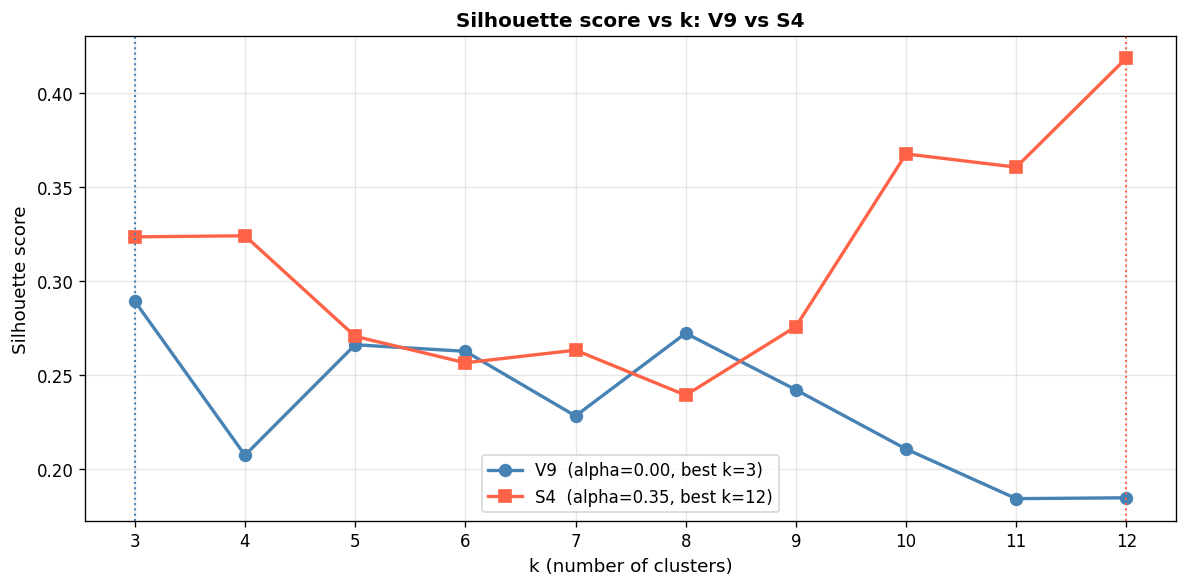

In [6]:
ks = sorted(scores_v9.keys())
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ks, [scores_v9[k] for k in ks], 'o-', color='steelblue', lw=2, ms=7,
        label=f'V9  (alpha=0.00, best k={k_v9})')
ax.plot(ks, [scores_s4[k] for k in ks], 's-', color='tomato', lw=2, ms=7,
        label=f'S4  (alpha={S4_ALPHA:.2f}, best k={k_s4})')
ax.axvline(k_v9, color='steelblue', ls=':', lw=1.2)
ax.axvline(k_s4, color='tomato',    ls=':', lw=1.2)
ax.set_xlabel('k (number of clusters)', fontsize=11)
ax.set_ylabel('Silhouette score', fontsize=11)
ax.set_title('Silhouette score vs k: V9 vs S4', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/v16_silhouette_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. PCA Scatter: V9 vs S4 at Best k, k=4, k=5

WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points


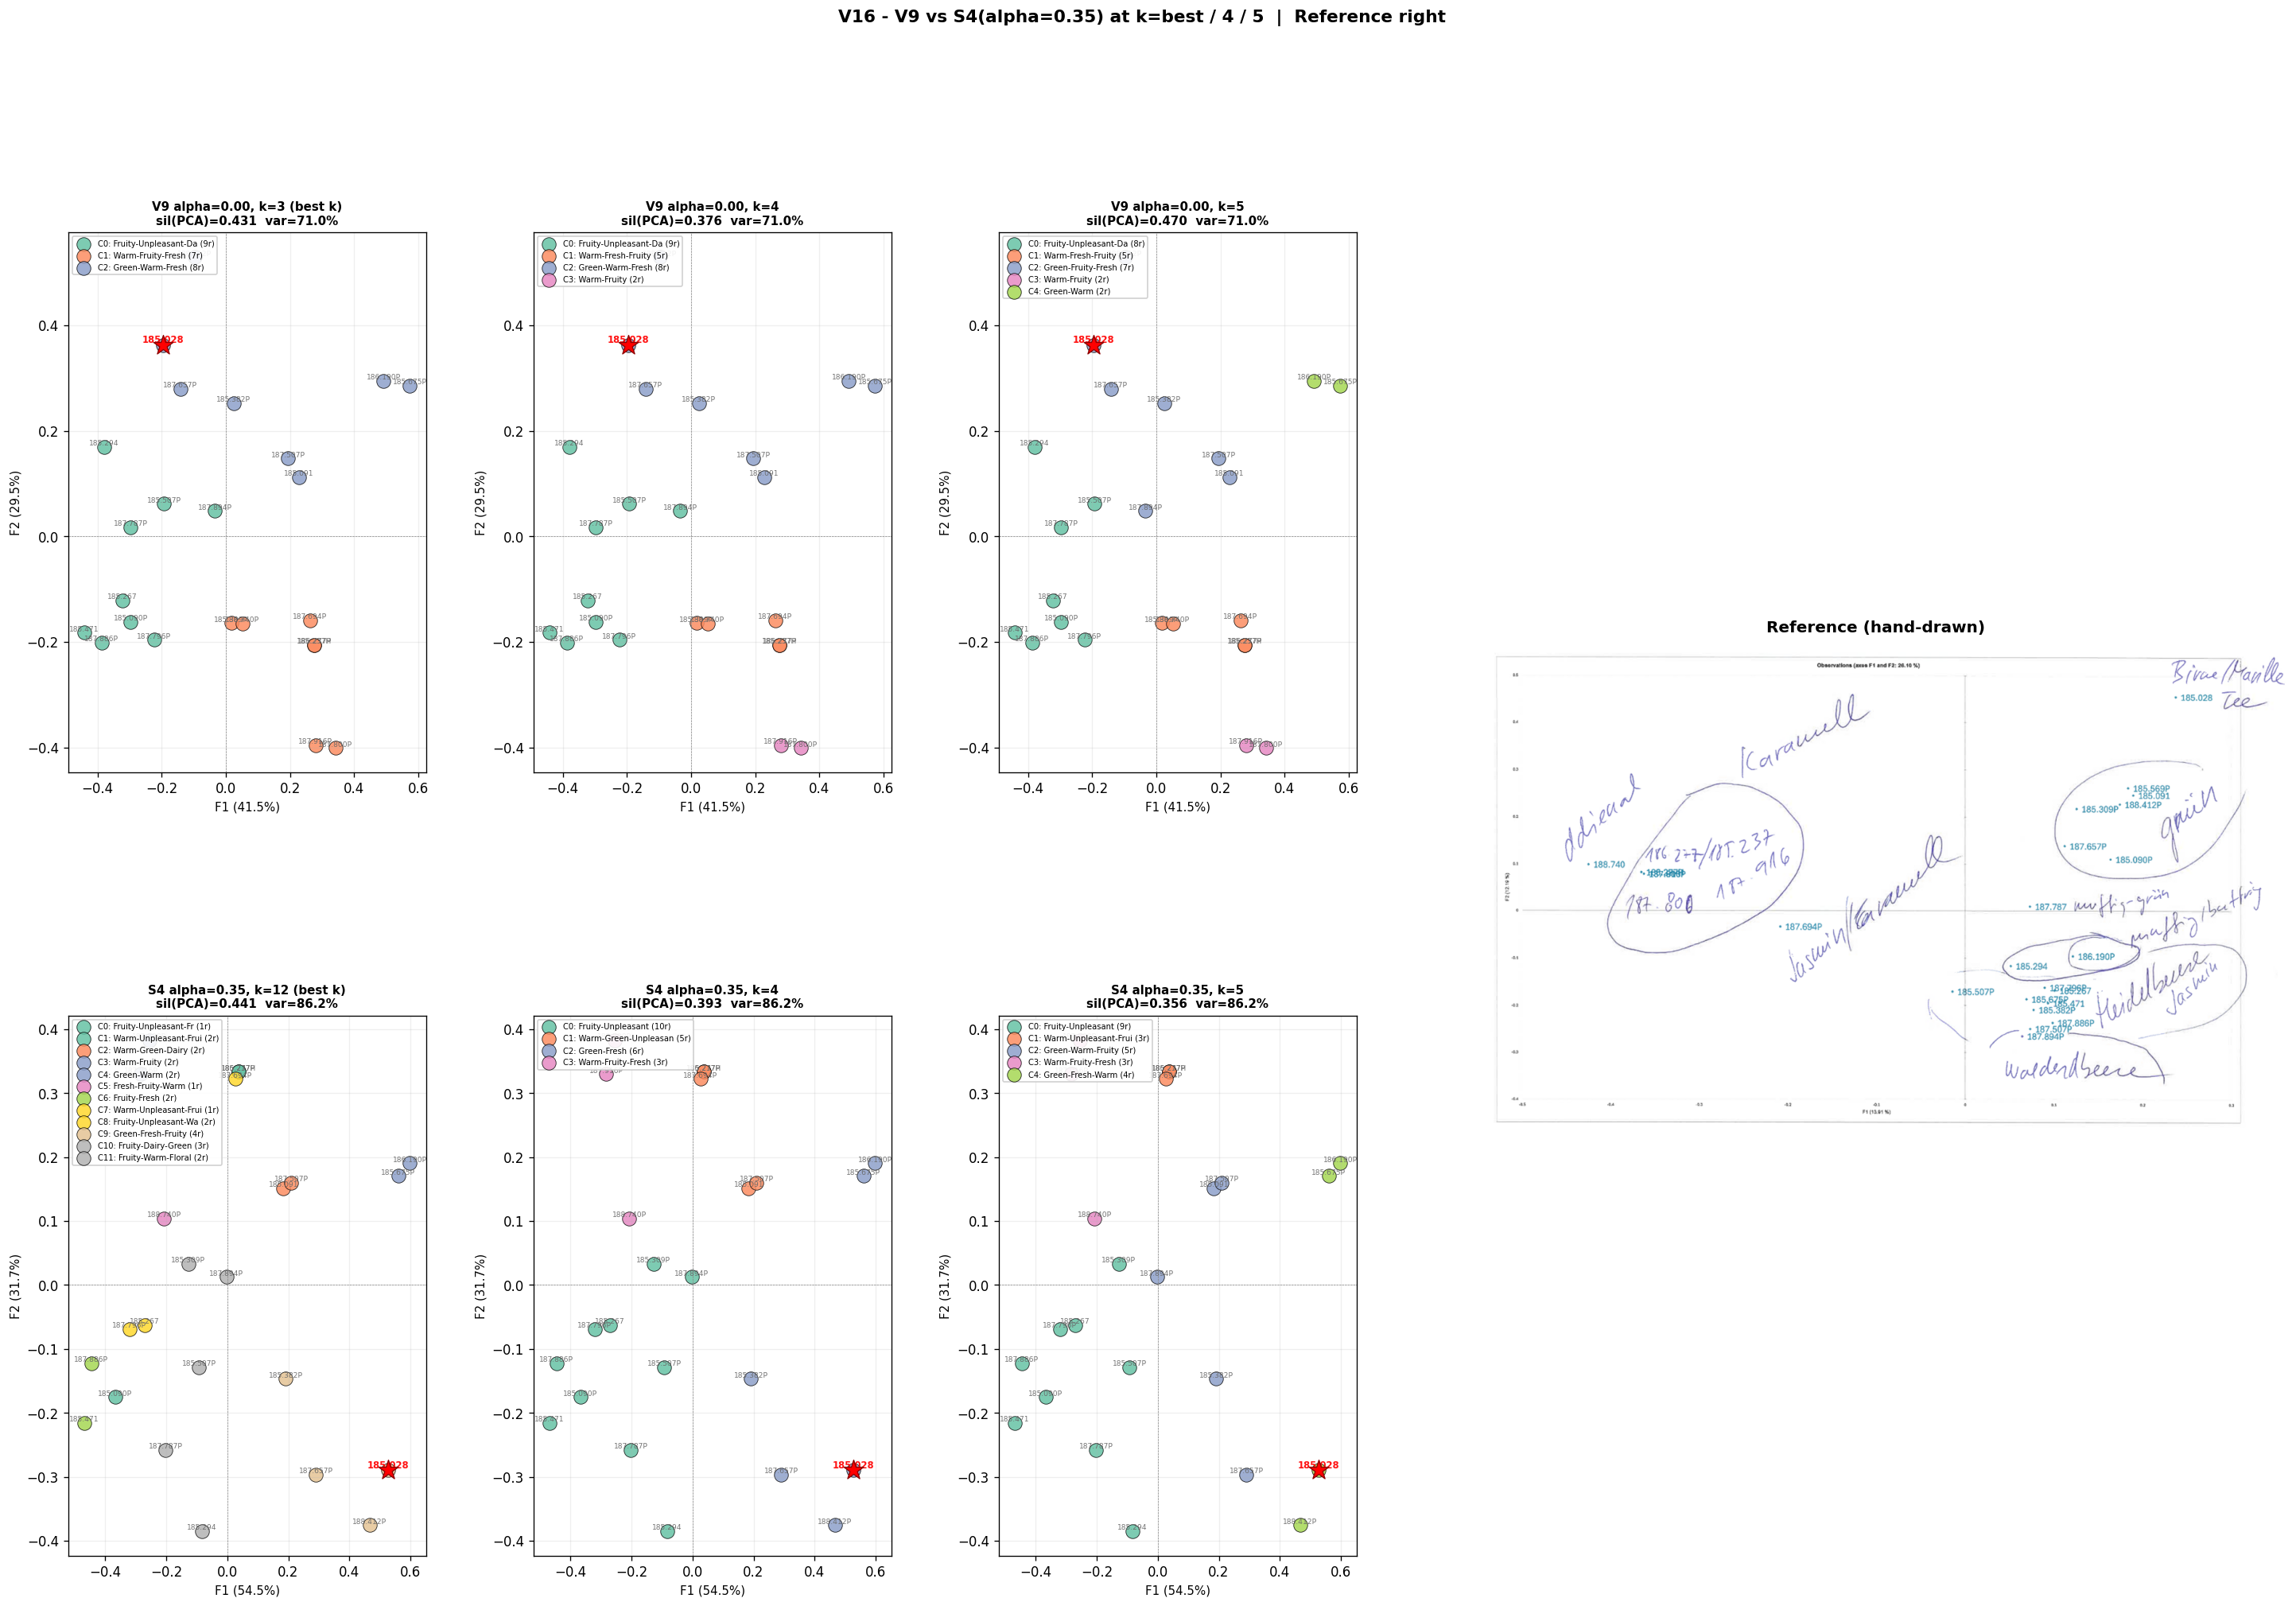

Saved: ../outputs/v16_v9_vs_s4_k_grid.png


In [7]:
def plot_pca(ax, coords, labels, cnames, ve, recipes, title):
    palette = plt.cm.Set2(np.linspace(0, 1, max(len(set(labels)), 8)))
    for j, cl in enumerate(sorted(set(labels))):
        mask = labels == cl
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=[palette[j % len(palette)]], s=110, alpha=0.85,
                   edgecolors='black', lw=0.5,
                   label=f'C{cl}: {cnames.get(cl,"")[:20]} ({mask.sum()}r)')
    for i, rec in enumerate(recipes):
        is_out = rec in OUTLIER_RECIPES
        ax.annotate(rec, (coords[i, 0], coords[i, 1]),
                    fontsize=7 if is_out else 5.5,
                    fontweight='bold' if is_out else 'normal',
                    color='red' if is_out else 'dimgray',
                    ha='center', va='bottom', alpha=0.92)
        if is_out:
            ax.scatter(coords[i, 0], coords[i, 1],
                       marker='*', s=240, c='red', zorder=5,
                       edgecolors='darkred', lw=0.8)
    ax.axhline(0, color='gray', lw=0.4, ls='--')
    ax.axvline(0, color='gray', lw=0.4, ls='--')
    ax.set_xlabel(f'F1 ({ve[0]:.1f}%)', fontsize=9)
    ax.set_ylabel(f'F2 ({ve[1]:.1f}%)', fontsize=9)
    sil = silhouette_score(coords, labels) if len(set(labels)) > 1 else 0
    ax.set_title(f'{title}\nsil(PCA)={sil:.3f}  var={sum(ve):.1f}%',
                 fontsize=9, fontweight='bold')
    ax.legend(loc='upper left', fontsize=6, framealpha=0.9)
    ax.grid(True, alpha=0.2)


# Build fixed-k variants for S4
k_variants = {}
for k_try in [k_v9, 4, 5, k_s4]:
    lbl, sil = cluster_at_k(vecs_s4, k_try)
    cn       = cluster_names(lbl, vecs_s4, vocab)
    k_variants[k_try] = (lbl, cn, sil)

fig = plt.figure(figsize=(30, 18))
gs  = gridspec.GridSpec(2, 5, figure=fig, wspace=0.3, hspace=0.45)

# Row 0: V9 variants
for ki, k_try in enumerate([k_v9, 4, 5]):
    lbl, sil = cluster_at_k(vecs_v9, k_try)
    cn       = cluster_names(lbl, vecs_v9, vocab)
    ax       = fig.add_subplot(gs[0, ki])
    star = ' (best k)' if k_try == k_v9 else ''
    plot_pca(ax, coords_v9, lbl, cn, ve_v9, recipes,
             f'V9 alpha=0.00, k={k_try}{star}')

# Row 1: S4 variants
for ki, k_try in enumerate([k_s4, 4, 5]):
    lbl, cn, _ = k_variants[k_try]
    ax         = fig.add_subplot(gs[1, ki])
    star = ' (best k)' if k_try == k_s4 else ''
    plot_pca(ax, coords_s4, lbl, cn, ve_s4, recipes,
             f'S4 alpha={S4_ALPHA:.2f}, k={k_try}{star}')

# Reference image spanning col 3-4, both rows
ax_ref = fig.add_subplot(gs[:, 3:])
if os.path.exists(REFERENCE_IMG):
    ax_ref.imshow(mpimg.imread(REFERENCE_IMG))
    ax_ref.set_title('Reference (hand-drawn)', fontsize=12, fontweight='bold')
ax_ref.axis('off')

fig.suptitle('V16 - V9 vs S4(alpha=0.35) at k=best / 4 / 5  |  Reference right',
             fontsize=13, fontweight='bold', y=1.01)
out = f'{OUTPUT_DIR}/v16_v9_vs_s4_k_grid.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## 6. Membership Diff: What Changed Between V9 and S4?

In [8]:
# Compare at the same k for a fair diff (use k=4 as reference-like)
K_COMPARE = 4
lbl_v9_k4, _ = cluster_at_k(vecs_v9, K_COMPARE)
lbl_s4_k4, _ = cluster_at_k(vecs_s4, K_COMPARE)
cnames_v9_k4 = cluster_names(lbl_v9_k4, vecs_v9, vocab)
cnames_s4_k4 = cluster_names(lbl_s4_k4, vecs_s4, vocab)

print(f'Cluster membership comparison at k={K_COMPARE}')
print(f'{"Recipe":<12} {"V9 cluster":<30} {"S4 cluster":<30} {"Changed?"}')
print('-' * 85)

moved = []
for i, rec in enumerate(recipes):
    v9_cl  = lbl_v9_k4[i]
    s4_cl  = lbl_s4_k4[i]
    v9_nm  = cnames_v9_k4.get(v9_cl, f'C{v9_cl}')
    s4_nm  = cnames_s4_k4.get(s4_cl, f'C{s4_cl}')
    # Use cluster index to determine if effectively same group (renumbering)
    changed = '  MOVED' if v9_cl != s4_cl else ''
    if changed:
        moved.append(rec)
    out_marker = '  (outlier)' if rec in OUTLIER_RECIPES else ''
    print(f'{rec:<12} C{v9_cl}: {v9_nm:<26} C{s4_cl}: {s4_nm:<26}{changed}{out_marker}')

print(f'\nRecipes that changed cluster: {len(moved)} / {len(recipes)}')
print(f'Recipes that moved: {moved}')

Cluster membership comparison at k=4
Recipe       V9 cluster                     S4 cluster                     Changed?
-------------------------------------------------------------------------------------
187.796P     C0: Fruity-Unpleasant-Dairy    C0: Fruity-Unpleasant         
185.028      C2: Green-Warm-Fresh           C2: Green-Fresh                 (outlier)
185.507P     C0: Fruity-Unpleasant-Dairy    C0: Fruity-Unpleasant         
187.894P     C0: Fruity-Unpleasant-Dairy    C0: Fruity-Unpleasant         
185.267      C0: Fruity-Unpleasant-Dairy    C0: Fruity-Unpleasant         
185.471      C0: Fruity-Unpleasant-Dairy    C0: Fruity-Unpleasant         
187.886P     C0: Fruity-Unpleasant-Dairy    C0: Fruity-Unpleasant         
185.091      C2: Green-Warm-Fresh           C1: Warm-Green-Unpleasant       MOVED
185.309P     C1: Warm-Fresh-Fruity          C0: Fruity-Unpleasant           MOVED
186.190P     C2: Green-Warm-Fresh           C2: Green-Fresh               
187.507P     C2: G

WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points


## 7. Deep Chemical Profile per Cluster (S4, k=4)

In [9]:
def oav(qty, raw_T):
    T = parse_threshold(raw_T)
    return qty / T if T is not None else 0.0

def cluster_profile(cluster_label, labels, recipes, df):
    cluster_recipes = [r for r, l in zip(recipes, labels) if l == cluster_label]
    rows = df[(df['Rez.-Nr.'].isin(cluster_recipes)) & (df['Totalmenge'] > 0)].copy()

    # OT1 share: sum of qty per family, averaged over recipes
    ot1_qty  = rows.groupby(OT1)['Totalmenge'].mean().sort_values(ascending=False)

    # OT1 OAV share
    rows['OAV'] = rows.apply(lambda r: oav(r['Totalmenge'], r.get(THRESHOLD_COL)), axis=1)
    total_oav   = rows['OAV'].sum()
    ot1_oav     = rows.groupby(OT1)['OAV'].sum() / total_oav if total_oav > 0 else rows.groupby(OT1)['OAV'].sum()
    ot1_oav     = ot1_oav.sort_values(ascending=False)

    # Top individual ingredients by OAV share
    rows['OAV_share'] = rows['OAV'] / total_oav if total_oav > 0 else rows['OAV']
    top_ingr = (rows.groupby('Name')
                    .agg(qty_mean=('Totalmenge','mean'), oav_share=('OAV_share','sum'))
                    .sort_values('oav_share', ascending=False)
                    .head(8))

    return cluster_recipes, ot1_qty, ot1_oav, top_ingr


print(f'Deep chemical profile - S4 (alpha={S4_ALPHA:.2f}), k={K_COMPARE}')
print('=' * 80)

for cl in sorted(set(lbl_s4_k4)):
    cn = cnames_s4_k4.get(cl, f'C{cl}')
    cluster_recipes, ot1_qty, ot1_oav, top_ingr = cluster_profile(
        cl, lbl_s4_k4, recipes, df)

    print(f'\nCluster {cl}: {cn}')
    print(f'  Recipes ({len(cluster_recipes)}): {cluster_recipes}')

    print(f'  OT1 share by QUANTITY (avg across cluster):')
    for fam, val in ot1_qty.head(6).items():
        bar = '#' * int(val * 40)
        print(f'    {str(fam):<28} {val*100:5.1f}%  {bar}')

    print(f'  OT1 share by OAV (odour contribution):')
    for fam, val in ot1_oav.head(6).items():
        bar = '#' * int(val * 40)
        print(f'    {str(fam):<28} {val*100:5.1f}%  {bar}')

    print(f'  Top ingredients by OAV share:')
    print(f'    {"Name":<45} {"qty%":>8} {"OAV share%":>12}')
    for name, row in top_ingr.iterrows():
        print(f'    {str(name)[:44]:<45} {row["qty_mean"]*100:>7.2f}% {row["oav_share"]*100:>11.2f}%')

Deep chemical profile - S4 (alpha=0.35), k=4

Cluster 0: Fruity-Unpleasant
  Recipes (10): ['187.796P', '185.507P', '187.894P', '185.267', '185.471', '187.886P', '185.309P', '187.787P', '185.090P', '185.294']
  OT1 share by QUANTITY (avg across cluster):
    fruity                         7.4%  ##
    dairy                          4.2%  #
    warm                           3.2%  #
    green                          2.8%  #
    unpleasant                     2.8%  #
    fresh                          1.8%  
  OT1 share by OAV (odour contribution):
    fruity                        45.9%  ##################
    warm                          20.0%  ########
    green                         10.9%  ####
    woody                          9.9%  ###
    floral                         5.6%  ##
    unpleasant                     5.2%  ##
  Top ingredients by OAV share:
    Name                                              qty%   OAV share%
    Ethylbutyrat, natürlich Kosher Halal BG         2

## 8. Same Profile for V9 (k=4) - to Compare

In [10]:
print(f'Deep chemical profile - V9 (alpha=0.00), k={K_COMPARE}')
print('=' * 80)

for cl in sorted(set(lbl_v9_k4)):
    cn = cnames_v9_k4.get(cl, f'C{cl}')
    cluster_recipes, ot1_qty, ot1_oav, top_ingr = cluster_profile(
        cl, lbl_v9_k4, recipes, df)

    print(f'\nCluster {cl}: {cn}')
    print(f'  Recipes ({len(cluster_recipes)}): {cluster_recipes}')

    print(f'  OT1 share by QUANTITY (avg across cluster):')
    for fam, val in ot1_qty.head(6).items():
        bar = '#' * int(val * 40)
        print(f'    {str(fam):<28} {val*100:5.1f}%  {bar}')

    print(f'  OT1 share by OAV (odour contribution):')
    for fam, val in ot1_oav.head(6).items():
        bar = '#' * int(val * 40)
        print(f'    {str(fam):<28} {val*100:5.1f}%  {bar}')

    print(f'  Top ingredients by OAV share:')
    print(f'    {"Name":<45} {"qty%":>8} {"OAV share%":>12}')
    for name, row in top_ingr.iterrows():
        print(f'    {str(name)[:44]:<45} {row["qty_mean"]*100:>7.2f}% {row["oav_share"]*100:>11.2f}%')

Deep chemical profile - V9 (alpha=0.00), k=4

Cluster 0: Fruity-Unpleasant-Dairy
  Recipes (9): ['187.796P', '185.507P', '187.894P', '185.267', '185.471', '187.886P', '187.787P', '185.090P', '185.294']
  OT1 share by QUANTITY (avg across cluster):
    fruity                         7.7%  ###
    dairy                          4.2%  #
    warm                           3.2%  #
    unpleasant                     2.8%  #
    green                          2.7%  #
    fresh                          1.9%  
  OT1 share by OAV (odour contribution):
    fruity                        51.3%  ####################
    warm                          21.5%  ########
    green                         11.6%  ####
    floral                         6.5%  ##
    unpleasant                     6.2%  ##
    dairy                          2.3%  
  Top ingredients by OAV share:
    Name                                              qty%   OAV share%
    Ethylbutyrat, natürlich Kosher Halal BG         26.55%  

## 9. Radar Profiles per Cluster (S4 k=4)

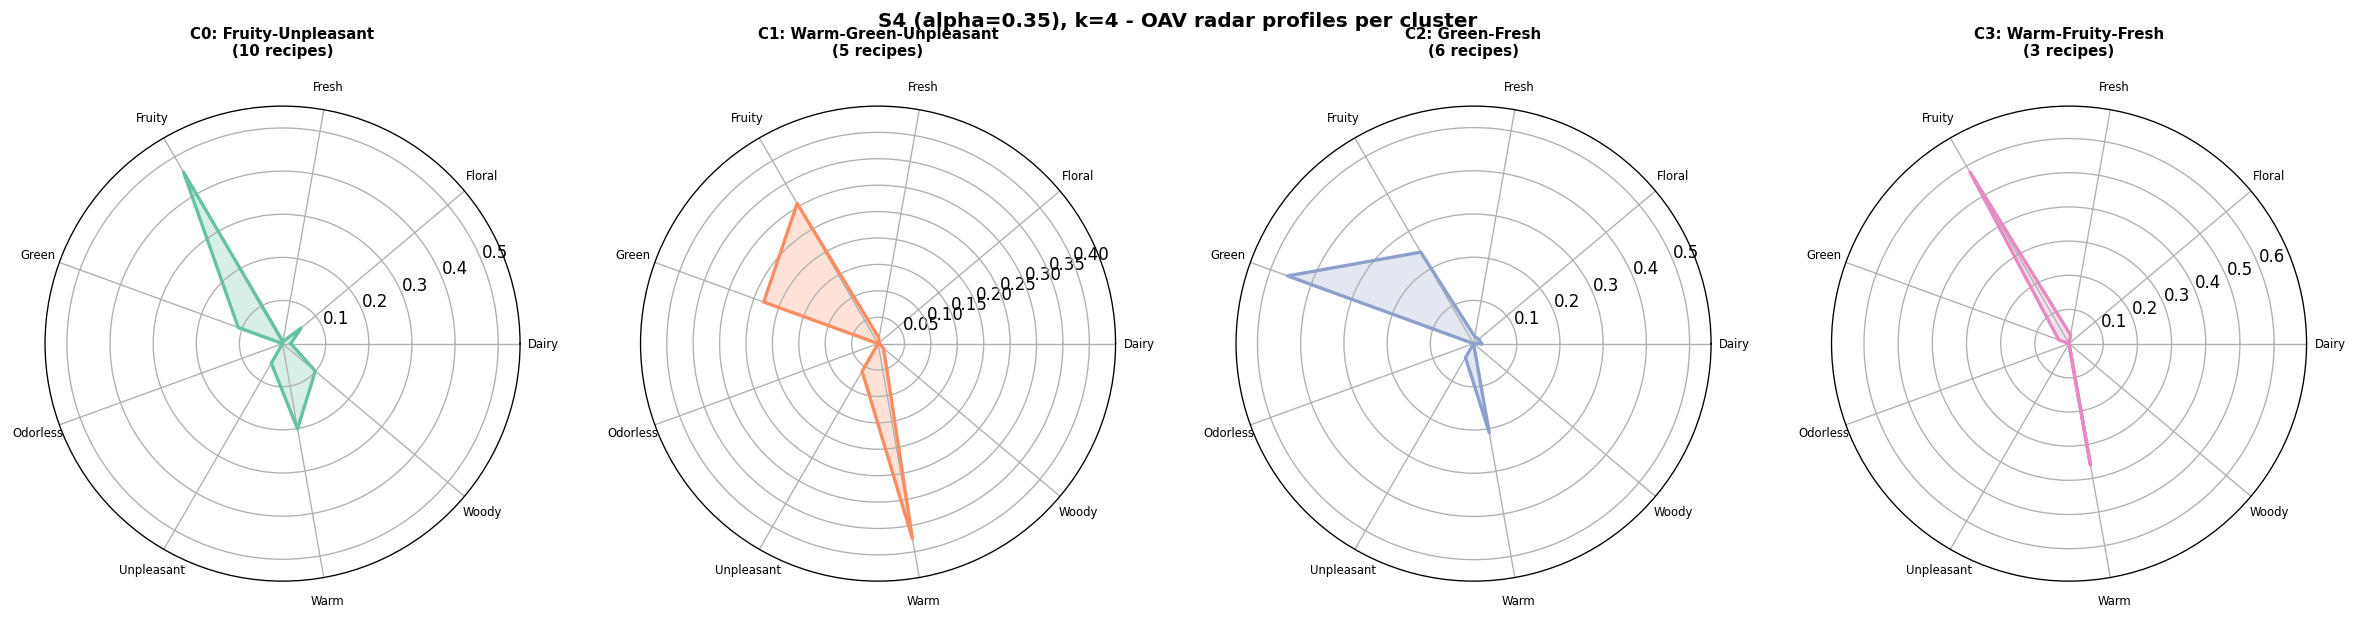

Saved: ../outputs/v16_radar_s4_k4.png


In [11]:
# Collect OT1 OAV profiles per cluster
all_families = sorted(df[OT1].dropna().map(norm_term).dropna().unique())

def oav_profile(cluster_label, labels, recipes, df, families):
    cluster_recipes = [r for r, l in zip(recipes, labels) if l == cluster_label]
    rows = df[(df['Rez.-Nr.'].isin(cluster_recipes)) & (df['Totalmenge'] > 0)].copy()
    rows['OAV'] = rows.apply(lambda r: oav(r['Totalmenge'], r.get(THRESHOLD_COL)), axis=1)
    total = rows['OAV'].sum()
    rows['fam'] = rows[OT1].map(norm_term)
    oav_by_fam = rows.groupby('fam')['OAV'].sum() / total if total > 0 else pd.Series(0, index=families)
    return np.array([oav_by_fam.get(f, 0.0) for f in families])

n_cl  = len(set(lbl_s4_k4))
n_fam = len(all_families)
angles = np.linspace(0, 2 * np.pi, n_fam, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, axes = plt.subplots(1, n_cl, figsize=(5 * n_cl, 5),
                          subplot_kw=dict(polar=True))
if n_cl == 1:
    axes = [axes]

palette = plt.cm.Set2(np.linspace(0, 1, max(n_cl, 8)))

for j, cl in enumerate(sorted(set(lbl_s4_k4))):
    cn      = cnames_s4_k4.get(cl, f'C{cl}')
    profile = oav_profile(cl, lbl_s4_k4, recipes, df, all_families)
    values  = profile.tolist() + profile[:1].tolist()
    ax      = axes[j]
    ax.plot(angles, values, lw=2, color=palette[j])
    ax.fill(angles, values, alpha=0.25, color=palette[j])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f.capitalize() for f in all_families], fontsize=7)
    ax.set_title(f'C{cl}: {cn}\n({sum(lbl_s4_k4==cl)} recipes)',
                 fontsize=9, fontweight='bold', pad=15)
    ax.set_ylim(0, max(profile) * 1.2 if max(profile) > 0 else 1)

plt.suptitle(f'S4 (alpha={S4_ALPHA:.2f}), k={K_COMPARE} - OAV radar profiles per cluster',
             fontsize=12, fontweight='bold')
plt.tight_layout()
radar_path = f'{OUTPUT_DIR}/v16_radar_s4_k{K_COMPARE}.png'
plt.savefig(radar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {radar_path}')

## 10. PCA Biplot for S4 - What Drives the Axes?

PCA loadings for S4 (alpha=0.35):
Term                              F1         F2
-----------------------------------------------
Dairy                        +0.0115    -0.0527
Floral                       +0.0087    +0.0075
Fresh                        -0.0052    -0.0454
Fruity                       -0.5638    -0.3435
Green                        +0.8214    -0.3088
Odorless                     +0.0000    +0.0000
Unpleasant                   -0.0555    -0.0755
Warm                         +0.0638    +0.8809
Woody                        -0.0050    +0.0061


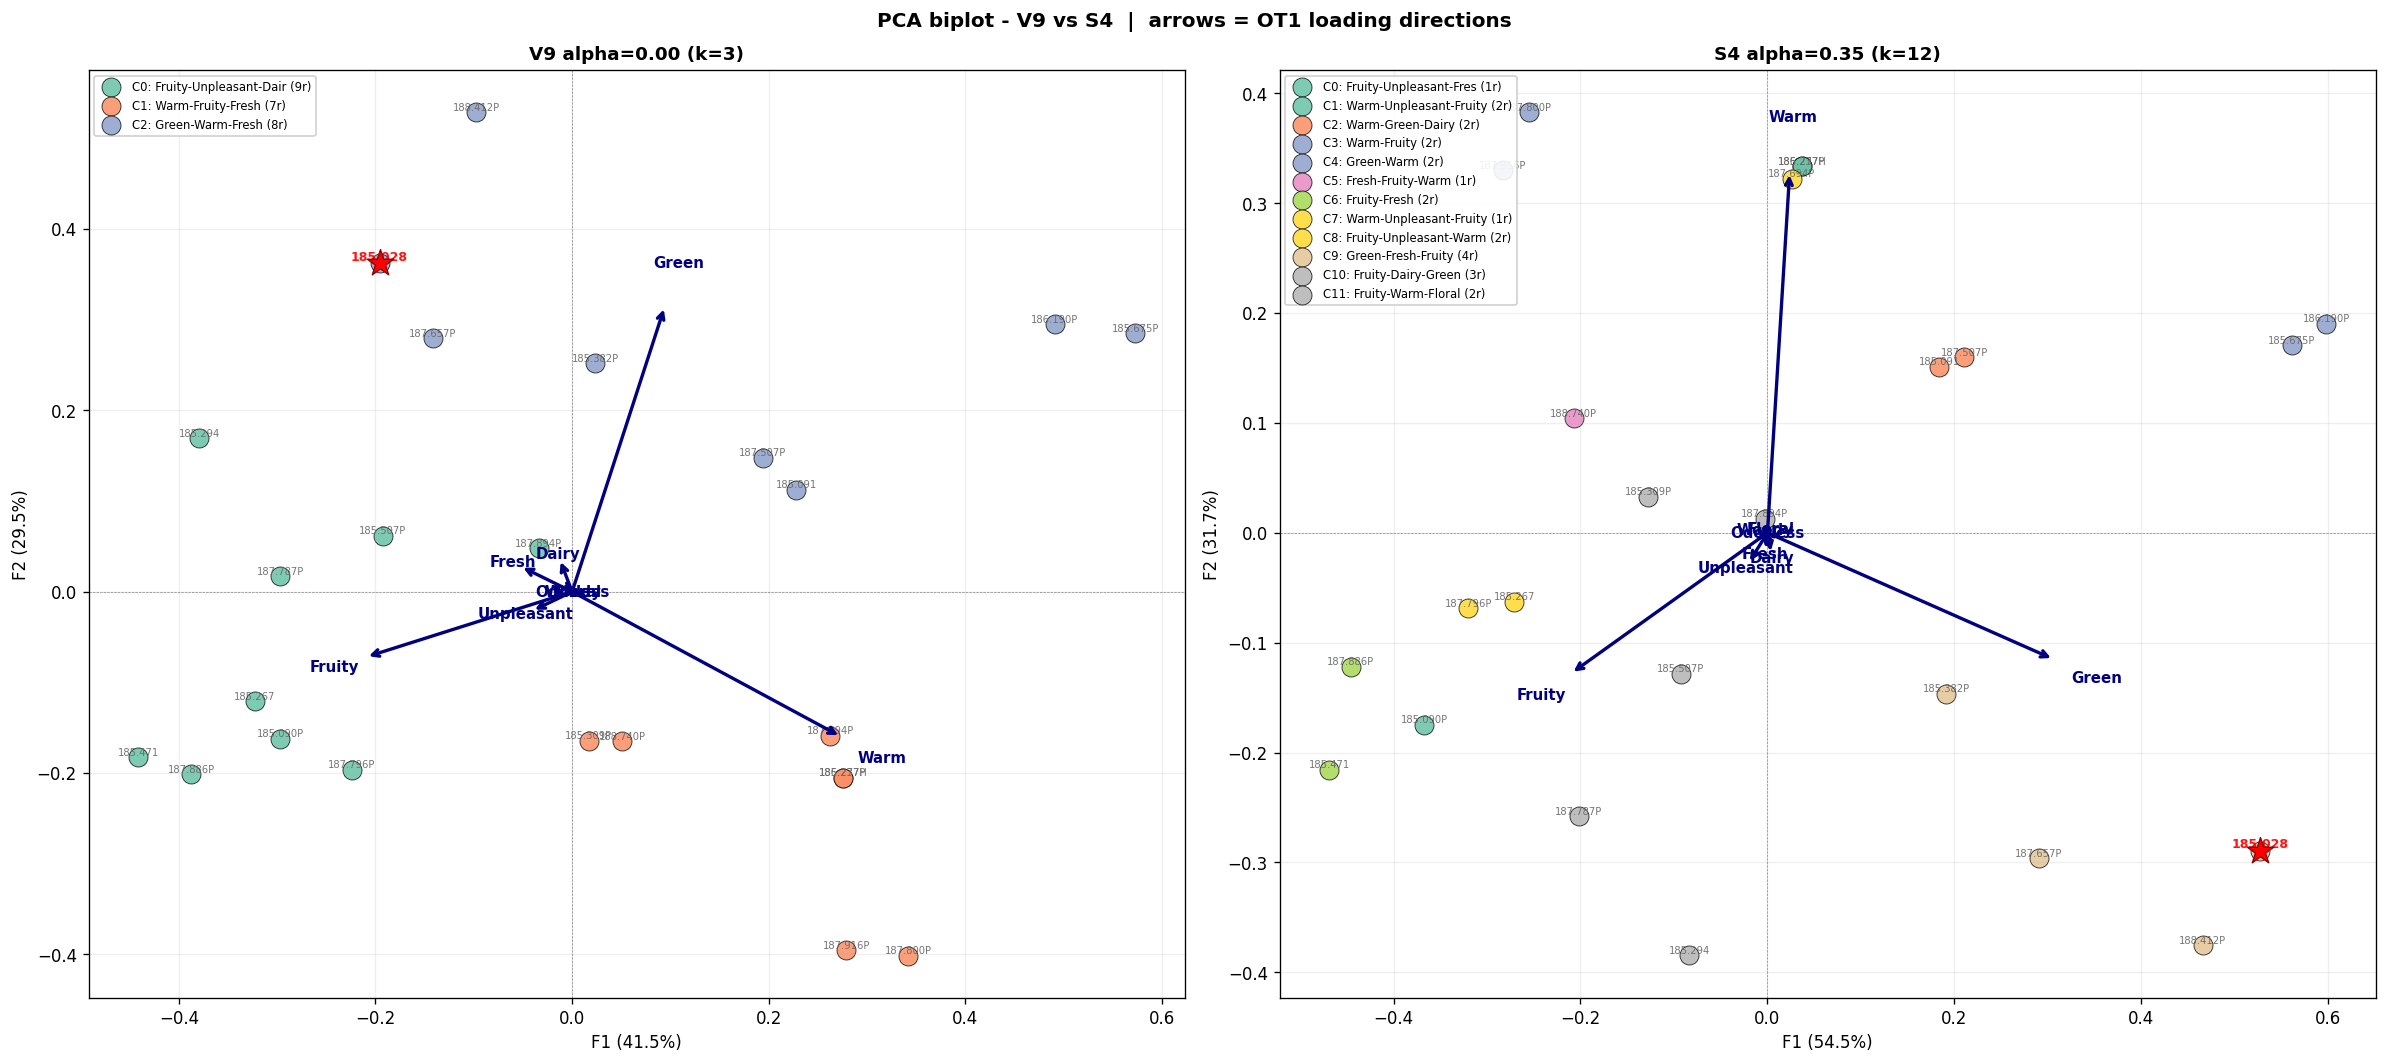

Saved: ../outputs/v16_biplot_v9_vs_s4.png


In [12]:
loadings = pca_s4.components_  # shape (2, n_vocab)

print(f'PCA loadings for S4 (alpha={S4_ALPHA:.2f}):')
print(f'{"Term":<25} {"F1":>10} {"F2":>10}')
print('-' * 47)
for i, term in enumerate(vocab):
    print(f'{term.capitalize():<25} {loadings[0,i]:>+10.4f} {loadings[1,i]:>+10.4f}')

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for ax_i, (ax, coords, labels, cnames, ve, pca_obj, title) in enumerate([
    (axes[0], coords_v9, lbl_v9, cnames_v9, ve_v9, pca_v9, f'V9 alpha=0.00 (k={k_v9})'),
    (axes[1], coords_s4, lbl_s4, cnames_s4, ve_s4, pca_s4, f'S4 alpha={S4_ALPHA:.2f} (k={k_s4})'),
]):
    palette = plt.cm.Set2(np.linspace(0, 1, max(len(set(labels)), 8)))
    for j, cl in enumerate(sorted(set(labels))):
        mask = labels == cl
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=[palette[j % len(palette)]], s=130, alpha=0.85,
                   edgecolors='black', lw=0.5,
                   label=f'C{cl}: {cnames.get(cl,"")[:22]} ({mask.sum()}r)')
    for i, rec in enumerate(recipes):
        is_out = rec in OUTLIER_RECIPES
        ax.annotate(rec, (coords[i,0], coords[i,1]),
                    fontsize=7.5 if is_out else 6,
                    fontweight='bold' if is_out else 'normal',
                    color='red' if is_out else 'dimgray',
                    ha='center', va='bottom', alpha=0.92)
        if is_out:
            ax.scatter(coords[i,0], coords[i,1],
                       marker='*', s=280, c='red', zorder=5,
                       edgecolors='darkred', lw=0.8)

    # Loading arrows
    ld = pca_obj.components_
    scale = 0.55 * np.abs(coords).max() / (np.abs(ld).max() + 1e-9)
    for i, term in enumerate(vocab):
        dx, dy = ld[0,i] * scale, ld[1,i] * scale
        ax.annotate('', xy=(dx, dy), xytext=(0,0),
                    arrowprops=dict(arrowstyle='->', color='navy', lw=2.0))
        ax.text(dx*1.15, dy*1.15, term.capitalize(),
                fontsize=9, color='navy', fontweight='bold',
                ha='center', va='center')

    ax.axhline(0, color='gray', lw=0.4, ls='--')
    ax.axvline(0, color='gray', lw=0.4, ls='--')
    ax.set_xlabel(f'F1 ({ve[0]:.1f}%)', fontsize=10)
    ax.set_ylabel(f'F2 ({ve[1]:.1f}%)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=7, framealpha=0.9)
    ax.grid(True, alpha=0.2)

plt.suptitle('PCA biplot - V9 vs S4  |  arrows = OT1 loading directions',
             fontsize=12, fontweight='bold')
plt.tight_layout()
biplot_path = f'{OUTPUT_DIR}/v16_biplot_v9_vs_s4.png'
plt.savefig(biplot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {biplot_path}')

## 11. Summary Table

In [13]:
print('Model comparison summary')
print('=' * 70)
for model_name, labels, cnames, ve, sil, k in [
    ('V9 alpha=0.00', lbl_v9, cnames_v9, ve_v9, sil_v9, k_v9),
    (f'S4 alpha={S4_ALPHA:.2f}', lbl_s4, cnames_s4, ve_s4, sil_s4, k_s4),
]:
    print(f'\n{model_name}: k={k}, sil={sil:.4f}, '
          f'PCA {ve[0]:.1f}%+{ve[1]:.1f}%={sum(ve):.1f}%')
    for cl in sorted(set(labels)):
        recs  = [r for r, l in zip(recipes, labels) if l == cl]
        flags = ' (contains outlier)' if any(r in OUTLIER_RECIPES for r in recs) else ''
        print(f'  C{cl} {cnames.get(cl,""):<30} {len(recs):>2} recipes: {recs}{flags}')

print()
print('Outlier recipe cluster assignments:')
for rec in OUTLIER_RECIPES:
    if rec not in recipes:
        continue
    idx    = recipes.index(rec)
    v9_cl  = lbl_v9[idx]
    s4_cl  = lbl_s4[idx]
    print(f'  {rec}: V9 -> C{v9_cl}({cnames_v9.get(v9_cl,"")}), '
          f'S4 -> C{s4_cl}({cnames_s4.get(s4_cl, "")})')

Model comparison summary

V9 alpha=0.00: k=3, sil=0.2893, PCA 41.5%+29.5%=71.0%
  C0 Fruity-Unpleasant-Dairy         9 recipes: ['187.796P', '185.507P', '187.894P', '185.267', '185.471', '187.886P', '187.787P', '185.090P', '185.294']
  C1 Warm-Fruity-Fresh               7 recipes: ['185.309P', '186.277P', '185.237H', '187.694P', '188.740P', '187.800P', '187.916P']
  C2 Green-Warm-Fresh                8 recipes: ['185.028', '185.091', '186.190P', '187.507P', '188.412P', '185.382P', '187.657P', '185.675P'] (contains outlier)

S4 alpha=0.35: k=12, sil=0.4185, PCA 54.5%+31.7%=86.2%
  C0 Fruity-Unpleasant-Fresh         1 recipes: ['185.090P']
  C1 Warm-Unpleasant-Fruity          2 recipes: ['186.277P', '185.237H']
  C2 Warm-Green-Dairy                2 recipes: ['185.091', '187.507P']
  C3 Warm-Fruity                     2 recipes: ['187.800P', '187.916P']
  C4 Green-Warm                      2 recipes: ['186.190P', '185.675P']
  C5 Fresh-Fruity-Warm               1 recipes: ['188.740P']
  

## 12. Key Findings

### S4 formula: qty x T^(-0.35)

A fractional exponent of 0.35 applies a soft potency amplification: each
ingredient is weighted by its quantity multiplied by its threshold raised
to the power -0.35. This is much gentler than the linear 1/T (exponent 1.0)
that collapsed the space in V13. Ingredients with very low thresholds still
get amplified, but by a factor proportional to T^(-0.35) rather than T^(-1),
so the range of weights is compressed from 5 orders of magnitude to roughly 2.

### What changed vs V9

The membership diff in section 6 shows which recipes moved clusters when
potency is partially accounted for. Recipes that contain ingredients with
unusually low thresholds (strong odorants) shift toward clusters whose
dominant character is defined by those odorants rather than by mass.

### Chemical sense check

The radar profiles (section 9) and OAV breakdowns (sections 7-8) answer
the key question: do the new cluster groupings reflect actual odour character
better than the pure-mass groupings? If the OAV profiles of recipes within
a cluster are more homogeneous in S4 than in V9, the answer is yes.

### Recommended model going forward

If the cluster memberships and radar profiles above show that S4 groups recipes
with more consistent odour character, then S4 (alpha=0.35, OT1 Grandfamilien,
PCA) replaces V9 as the best model. The silhouette improvement (0.419 vs 0.289)
is already strong quantitative support; the chemical profile comparison here
provides the qualitative validation.